# Assignment 3

<br> 
    <center>
        <img src="src/A3_Cluster_illustration.png" width="350"/>
    </center>
</br>

In the third assignment, you can revise dimensionality reduction with **principal component analysis (PCA)** and **k-means clustering**. Here, we focus on two datasets of stock prices. In particular, you will see examples of 

* when principal components might be useful as new variables for a predictive model,
* how to recognise whether principal components carry sufficient information,
* and identify clusters of similar assets in the finance example.

For this exercise, you can switch back to the environment ```APML``` used during class.

Please provide solutions to all exercises below and send me all notebooks by **28th of June 2026**.

***

## Part I: Portfolio of four industries

For the first part, we consider a portfolio of companies belonging to four industries: 

* automotive (Mercedes-Benz: 'MBG.DE', BMW: 'BMW.DE')
* aviation (Lufthansa: 'LHA.DE', Air France-KLM 'AF.PA') 
* pharmaceuticals (Bayer: 'BAYN.DE', Novartis: 'NVS', Roche: 'RO.SW')
* technology (Apple: 'AAPL', Amazon: 'AMZN', Google: 'GOOG')

In [44]:
portfolio = {
    "MBG.DE": "Mercedes-Benz Group AG",
    "BMW.DE": "Bayerische Motoren Werke AG",
    "LHA.DE": "Deutsche Lufthansa AG",
    "AF.PA": "Air France-KLM",
    "BAYN.DE": "Bayer AG",
    "NVS": "Novartis AG",
    "RO.SW": "Roche Holding AG",
    "AAPL": "Apple Inc.",
    "AMZN": "Amazon.com Inc.",
    "GOOG": "Alphabet Inc.",
}

Let us first inspect the dataset. Load the data with the following cell:

In [45]:
import pandas as pd
import numpy as np

pd.set_option("display.precision", 2)

industries_df = pd.read_csv("data/finance_toy_data.csv", index_col="Date")
industries_df

,MBG.DE,BMW.DE,LHA.DE,AF.PA,BAYN.DE,NVS,RO.SW,AAPL,AMZN,GOOG
Date,,,,,,,,,,
2016-01-04,50.6099,64.8802,13.4140,7.2500,83.9825,56.9032,216.1927,24.0747,31.8495,37.0920
2016-01-05,50.6030,64.5778,13.8310,7.4900,84.1338,57.2085,219.8160,23.4714,31.6895,37.1290
2016-01-06,49.3178,62.4397,14.0488,7.5500,82.9238,56.4255,216.9979,23.0121,31.6325,37.1810
2016-01-07,47.4210,60.0907,13.9098,7.5810,80.8063,55.7021,214.5823,22.0409,30.3970,36.3195
2016-01-08,46.8643,58.6841,13.8264,7.6760,78.5753,54.1228,210.1538,22.1574,30.3525,35.7235
...,...,...,...,...,...,...,...,...,...,...
2021-12-23,64.8672,82.8828,6.2890,3.9600,45.1425,79.7133,395.2256,174.9956,171.0685,147.1425
2021-12-27,64.6821,83.6543,6.2580,3.9340,45.5927,80.5872,402.4506,179.0161,169.6695,148.0640
2021-12-28,64.4137,83.6078,6.2950,3.9390,45.6508,81.0655,404.2080,177.9837,170.6610,146.4480


### Exercise I.1

As you can see above, the stock prices vary quite a bit from one company to another.

To normalise the values, we use **normalised returns**. To this end, calculate the 
fractional change from the immediately previous row. For example, the stock price of
```MBG.DE``` decreased on ```2016-01-06``` compared to previous day ```2016-01-05``` by

$\frac{49.32 - 50.60}{50.60} = \frac{-1.28}{50.60} \approx -0.025296$

i.e. by about 2.5296%.

* Compute the normalised returns for ```industries_df``` (i.e do a similar computation as above for all rows) and store the result in DataFrame ```norm_returns```.
* Drop all rows in ```norm_returns``` where there is at least one ```NaN``` entry
* Finally, transpose ```norm_returns``` such that rows represent different companies and columns different dates.

Fill in the cell below:

In [46]:
import pandas as pd
import numpy as np

# This calculates: (today - yesterday) / yesterday
# It tells us: "how much did the price change in percent?"
norm_returns = industries_df.pct_change()
print("Before dropping empty rows:")
display(norm_returns)

# dropna() means "drop rows that have any empty (NaN) values"
norm_returns = norm_returns.dropna()
print("After dropping empty rows:")
display(norm_returns)

# .T flips rows and columns
norm_returns = norm_returns.T
print("After flipping (transposing):")
display(norm_returns)

Before dropping empty rows:


,MBG.DE,BMW.DE,LHA.DE,AF.PA,BAYN.DE,NVS,RO.SW,AAPL,AMZN,GOOG
Date,,,,,,,,,,
2016-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-05,-0.0001,-0.0047,0.0311,0.0331,0.0018,0.0054,0.0168,-0.0251,-0.0050,0.0010
2016-01-06,-0.0254,-0.0331,0.0157,0.0080,-0.0144,-0.0137,-0.0128,-0.0196,-0.0018,0.0014
2016-01-07,-0.0385,-0.0376,-0.0099,0.0041,-0.0255,-0.0128,-0.0111,-0.0422,-0.0391,-0.0232
2016-01-08,-0.0117,-0.0234,-0.0060,0.0125,-0.0276,-0.0284,-0.0206,0.0053,-0.0015,-0.0164
...,...,...,...,...,...,...,...,...,...,...
2021-12-23,0.0057,0.0198,0.0098,-0.0008,0.0196,0.0041,-0.0039,0.0036,0.0002,0.0013
2021-12-27,-0.0029,0.0093,-0.0049,-0.0066,0.0100,0.0110,0.0183,0.0230,-0.0082,0.0063
2021-12-28,-0.0041,-0.0006,0.0059,0.0013,0.0013,0.0059,0.0044,-0.0058,0.0058,-0.0109


After dropping empty rows:


,MBG.DE,BMW.DE,LHA.DE,AF.PA,BAYN.DE,NVS,RO.SW,AAPL,AMZN,GOOG
Date,,,,,,,,,,
2016-01-05,-0.0001,-0.0047,0.0311,0.0331,0.0018,0.0054,0.0168,-0.0251,-0.0050,0.0010
2016-01-06,-0.0254,-0.0331,0.0157,0.0080,-0.0144,-0.0137,-0.0128,-0.0196,-0.0018,0.0014
2016-01-07,-0.0385,-0.0376,-0.0099,0.0041,-0.0255,-0.0128,-0.0111,-0.0422,-0.0391,-0.0232
2016-01-08,-0.0117,-0.0234,-0.0060,0.0125,-0.0276,-0.0284,-0.0206,0.0053,-0.0015,-0.0164
2016-01-11,-0.0009,-0.0036,-0.0178,0.0103,-0.0106,0.0010,-0.0096,0.0162,0.0176,0.0022
...,...,...,...,...,...,...,...,...,...,...
2021-12-23,0.0057,0.0198,0.0098,-0.0008,0.0196,0.0041,-0.0039,0.0036,0.0002,0.0013
2021-12-27,-0.0029,0.0093,-0.0049,-0.0066,0.0100,0.0110,0.0183,0.0230,-0.0082,0.0063
2021-12-28,-0.0041,-0.0006,0.0059,0.0013,0.0013,0.0059,0.0044,-0.0058,0.0058,-0.0109


After flipping (transposing):


Date,2016-01-05,2016-01-06,2016-01-07,2016-01-08,2016-01-11,2016-01-12,2016-01-13,2016-01-14,2016-01-15,2016-01-18,...,2021-12-16,2021-12-17,2021-12-20,2021-12-21,2021-12-22,2021-12-23,2021-12-27,2021-12-28,2021-12-29,2021-12-30
MBG.DE,-0.0001,-0.0254,-0.0385,-0.0117,-0.0009,0.0148,-0.0130,-0.0356,-0.0194,0.0060,...,0.0087,-0.0417,-0.0211,0.0196,0.0156,0.0057,-0.0029,-0.0041,-0.0197,-0.0094
BMW.DE,-0.0047,-0.0331,-0.0376,-0.0234,-0.0036,0.0206,-0.0231,-0.0335,-0.0261,0.0010,...,0.0155,-0.0303,-0.0199,0.0223,0.0040,0.0198,0.0093,-0.0006,-0.0083,-0.0080
LHA.DE,0.0311,0.0157,-0.0099,-0.0060,-0.0178,-0.0208,-0.0021,-0.0342,-0.0159,-0.0143,...,0.0092,0.0416,-0.0196,0.0658,-0.0008,0.0098,-0.0049,0.0059,-0.0078,-0.0106
AF.PA,0.0331,0.0080,0.0041,0.0125,0.0103,-0.0074,0.0034,-0.0225,-0.0181,-0.0066,...,-0.0045,0.0176,-0.0097,0.0448,0.0063,-0.0008,-0.0066,0.0013,-0.0124,-0.0036
BAYN.DE,0.0018,-0.0144,-0.0255,-0.0276,-0.0106,0.0136,0.0014,-0.0144,-0.0219,0.0045,...,0.0165,-0.0039,-0.0251,0.0055,0.0027,0.0196,0.0100,0.0013,-0.0042,0.0011
NVS,0.0054,-0.0137,-0.0128,-0.0284,0.0010,0.0073,-0.0140,0.0199,-0.0299,0.0000,...,0.0558,-0.0020,-0.0064,0.0075,0.0037,0.0041,0.0110,0.0059,-0.0001,-0.0075
RO.SW,0.0168,-0.0128,-0.0111,-0.0206,-0.0096,0.0155,0.0019,-0.0181,-0.0174,-0.0010,...,0.0195,-0.0088,-0.0030,0.0080,0.0025,-0.0039,0.0183,0.0044,-0.0082,-0.0044
AAPL,-0.0251,-0.0196,-0.0422,0.0053,0.0162,0.0145,-0.0257,0.0219,-0.0240,0.0000,...,-0.0393,-0.0065,-0.0081,0.0191,0.0153,0.0036,0.0230,-0.0058,0.0005,-0.0066
AMZN,-0.0050,-0.0018,-0.0391,-0.0015,0.0176,0.0002,-0.0584,0.0192,-0.0385,0.0000,...,-0.0256,0.0068,-0.0173,0.0200,0.0036,0.0002,-0.0082,0.0058,-0.0086,-0.0033
GOOG,0.0010,0.0014,-0.0232,-0.0164,0.0022,0.0140,-0.0351,0.0202,-0.0284,0.0000,...,-0.0172,-0.0141,-0.0028,0.0128,0.0189,0.0013,0.0063,-0.0109,0.0004,-0.0034


### Exercise I.2

Perform a principal component analysis on ```norm_returns```. Consider 
only the first two eigenvectors, i.e. use ```num_eigvectors = 2``` in your PCA function call.

In [47]:
from sklearn.decomposition import PCA

# Turn OFF scientific notation (the e-01, e-02 stuff)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

num_eigvectors = 2

# Create the PCA magic machine
pca = PCA(n_components=num_eigvectors)

# Fit the machine on our data and transform it
pca_result = pca.fit_transform(norm_returns)

# Turn the numbers into a NICE table with labels!
pca_df = pd.DataFrame(
    pca_result,  # The numbers
    index=portfolio.keys(),  # Row names: company abbreviations
    columns=["PC1", "PC2"],  # Column names
)

print(pca_df)

            PC1     PC2
MBG.DE   0.1023  0.4042
BMW.DE   0.0840  0.3308
LHA.DE   0.6336 -0.1434
AF.PA    0.7248 -0.2995
BAYN.DE -0.0137  0.2983
NVS     -0.2156 -0.0039
RO.SW   -0.1850  0.0710
AAPL    -0.3775 -0.2004
AMZN    -0.4324 -0.2953
GOOG    -0.3204 -0.1618


### Exercise I.3

Can you think of a metric which might give us an idea of how expressive the first principal components are?

Fill in the cell below with your choice:

In [48]:
# Ask the PCA machine: "How much information did we keep?"
explained_variance = pca.explained_variance_ratio_

# Show the score for PC1 and PC2
print("PC1 kept this much information:", explained_variance[0])
print("PC2 kept this much information:", explained_variance[1])

# Add them together to see the total
total_kept = explained_variance[0] + explained_variance[1]
print("Together, PC1 + PC2 kept this much:", total_kept)

# Turn it into a percentage (easier to read)
print("That is", total_kept * 100, "% of all the information")

PC1 kept this much information: 0.402731217909455
PC2 kept this much information: 0.17428425078400148
Together, PC1 + PC2 kept this much: 0.5770154686934564
That is 57.70154686934564 % of all the information


### Exercise I.4

Visualise the result of your PCA by plotting the first two principal components. 
Label the individual data points with the abbreviations given in 
the ```portfolio``` dictionary. Your result should look somewhat similar to the
title picture of this notebook above.

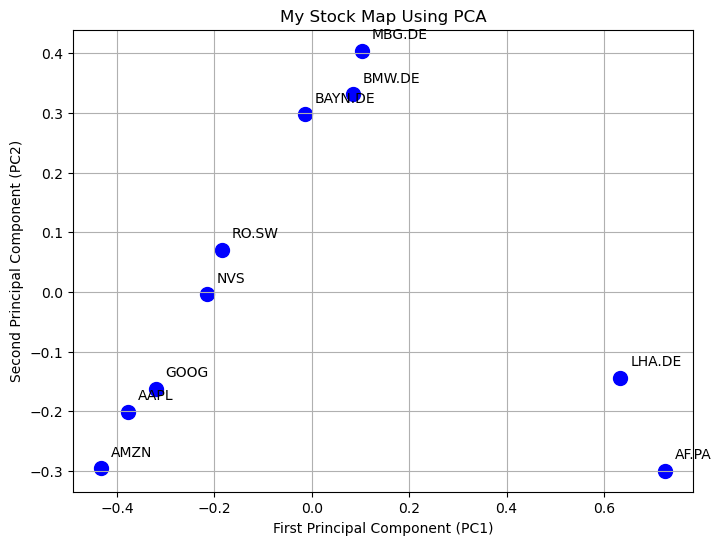

In [49]:
import matplotlib.pyplot as plt

# Step 1: Get the coordinates
# PC1 is the first column (left-right position)
# PC2 is the second column (up-down position)
x = pca_result[:, 0]
y = pca_result[:, 1]

# Step 2: Make a new picture
plt.figure(figsize=(8, 6))

# Step 3: Draw a blue dot for each company
plt.scatter(x, y, s=100, color="blue")

# Step 4: Write the company name next to each dot
company_names = list(portfolio.keys())

for i in range(len(company_names)):
    # +0.02 moves the text a tiny bit so it doesn't sit ON the dot
    plt.text(x[i] + 0.02, y[i] + 0.02, company_names[i])

# Step 5: Add labels and grid
plt.xlabel("First Principal Component (PC1)")
plt.ylabel("Second Principal Component (PC2)")
plt.title("My Stock Map Using PCA")
plt.grid(True)

# Step 6: Show the picture
plt.show()

### Exercise I.5

Perform k-means clustering on your PCA result. Use

In [50]:
k = 4
random_state = 123
n_init = 100

in your k-means clustering function.

In [51]:
from sklearn.cluster import KMeans

# Create the clustering robot
robot = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)

# Tell the robot to learn from our 2D map
robot.fit(pca_result)

# Ask the robot: "Which team number does each company belong to?"
cluster_labels = robot.predict(pca_result)

# Show the result!
company_names = list(portfolio.keys())

print("Cluster assignments:")
for i in range(len(company_names)):
    print(f"  {company_names[i]} is in Cluster {cluster_labels[i]}")

Cluster assignments:
  MBG.DE is in Cluster 1
  BMW.DE is in Cluster 1
  LHA.DE is in Cluster 0
  AF.PA is in Cluster 0
  BAYN.DE is in Cluster 1
  NVS is in Cluster 3
  RO.SW is in Cluster 3
  AAPL is in Cluster 2
  AMZN is in Cluster 2
  GOOG is in Cluster 2


### Exercise I.6

Visualise your result by plotting a similar figure as in Exercise I.4, 
but this time colour the data points by their cluster. Your result should 
resemble the title picture of this notebook above.

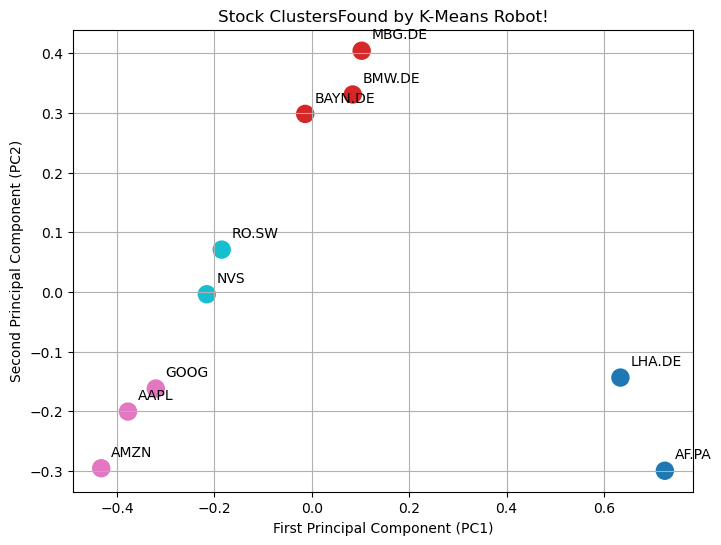

In [52]:
# Get coordinates again
x = pca_result[:, 0]
y = pca_result[:, 1]

# Make the picture bigger and nicer
plt.figure(figsize=(8, 6))

# Draw dots, but COLOR them by cluster number
plt.scatter(x, y, c=cluster_labels, cmap="tab10", s=150)

# Add company names
company_names = list(portfolio.keys())
for i in range(len(company_names)):
    plt.text(x[i] + 0.02, y[i] + 0.02, company_names[i])

# Labels and title
plt.xlabel("First Principal Component (PC1)")
plt.ylabel("Second Principal Component (PC2)")
plt.title("Stock ClustersFound by K-Means Robot!")
plt.grid(True)

plt.show()

In addition, print the cluster number (0 to 3) and the stocks which belong to each cluster number.

Fill in the cell below:

In [ ]:
# Print team members in a clean list
company_names = list(portfolio.keys())

for team_num in range(k):
    print(f"Cluster {team_num}:")

    # Find all companies in this team
    members = []
    for i in range(len(company_names)):
        if cluster_labels[i] == team_num:
            members.append(company_names[i])

    print(" ", members)
    print()

# strangely Bayer went into automotive, likely as we threw away so much data by squashing into only two components

Cluster 0:
  ['LHA.DE', 'AF.PA']

Cluster 1:
  ['MBG.DE', 'BMW.DE', 'BAYN.DE']

Cluster 2:
  ['AAPL', 'AMZN', 'GOOG']

Cluster 3:
  ['NVS', 'RO.SW']



### Exercise I.7

**You do not need to write or execute anything in this exercise.**

Reflect on the following questions:

* Were you able to identify clusters which correspond to the four industries?
* If you were or were not, why is that the case? Take your result on the expressivity (Exercise I.3) into consideration.
* Finally, do you consider the simplification to two principal components useful for this dataset?

***

## Part II: Portfolio of DAX companies

In the first part, we focused on handpicked companies in four distinct industries. 
In the second part, we consider a broader scope but essentially perform the same steps. 

Here, we work with the German stock market index DAX, which includes the 40 biggest German companies. 
Below, we focus on the following 27 DAX companies:

In [57]:
portfolio = {
    "ADS.DE": "Adidas AG",
    "ALV.DE": "Allianz SE",
    "BAS.DE": "BASF SE",
    "BAYN.DE": "Bayer AG",
    "BEI.DE": "Beiersdorf AG",
    "BMW.DE": "Bayerische Motoren Werke AG",
    "CON.DE": "Continental AG",
    "DB1.DE": "Deutsche Boerse AG",
    "DBK.DE": "Deutsche Bank AG",
    "DHER.DE": "Delivery Hero SE",
    "DPW.DE": "Deutsche Post AG",
    "DTE.DE": "Deutsche Telekom AG",
    "DWNI.DE": "Deutsche Wohnen SE",
    "EOAN.DE": "E.ON SE",
    "FME.DE": "Fresenius Medical Care AG & Co. KGaA",
    "FRE.DE": "Fresenius SE & Co. KGaA",
    "HEI.DE": "HeidelbergCement AG",
    "HEN3.DE": "Henkel AG & Co. KGaA",
    "IFX.DE": "Infineon Technologies AG",
    "LHA.DE": "Deutsche Lufthansa AG",
    "MRK.DE": "Merck KGaA",
    "MUV2.DE": "Muenchener Rückversicherungs-Gesellschaft AG",
    "RWE.DE": "RWE AG",
    "SAP.DE": "SAP SE",
    "SIE.DE": "Siemens AG",
    "TKA.DE": "thyssenkrupp AG",
    "VOW3.DE": "Volkswagen AG",
}

Load the dataset in the following cell:

In [58]:
import pandas as pd
import numpy as np

pd.set_option("display.precision", 2)

dax_df = pd.read_csv("data/finance_dax_data.csv", index_col="Date")
dax_df

,ADS.DE,ALV.DE,BAS.DE,BAYN.DE,BEI.DE,BMW.DE,CON.DE,DB1.DE,DBK.DE,DHER.DE,...,HEN3.DE,IFX.DE,LHA.DE,MRK.DE,MUV2.DE,RWE.DE,SAP.DE,SIE.DE,TKA.DE,VOW3.DE
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,78.0047,111.4058,44.8295,83.9825,76.8247,64.8802,170.0996,66.4573,18.0203,NaN,...,84.2192,11.9536,13.4140,78.1567,130.2934,8.7208,63.2606,66.1728,16.6692,90.4570
2016-01-05,77.7374,111.7629,44.5774,84.1338,77.6581,64.5778,171.1662,66.2529,18.3101,NaN,...,83.9639,11.8167,13.8311,79.4903,129.8546,8.9052,64.0224,66.5906,16.8163,86.8788
2016-01-06,76.8374,112.1200,43.8345,82.9238,77.1562,62.4397,165.7543,65.4267,18.1589,NaN,...,83.5385,11.4518,14.0488,78.3835,130.2203,8.9493,64.5781,66.3276,16.4841,85.0897
2016-01-07,75.6434,109.7990,42.7665,80.8062,75.2716,60.0907,161.7250,63.8681,17.7682,NaN,...,81.6921,11.1689,13.9098,75.8796,127.8067,8.7048,63.9418,65.0587,15.8957,82.2987
2016-01-08,74.3602,108.4064,42.2424,78.5753,75.0821,58.6841,160.2239,63.3571,17.1928,NaN,...,81.0880,10.8860,13.8264,75.3988,126.4171,8.5284,63.6818,64.6100,15.5304,82.3702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-23,247.2941,196.5312,56.7272,45.1425,89.3528,82.8828,90.7129,142.9586,10.9562,98.4200,...,68.4764,39.3044,6.2890,222.8995,244.5636,34.2795,122.8450,141.9122,9.3104,144.3484
2021-12-27,248.3249,197.0534,57.1562,45.5927,89.4123,83.6543,90.8386,143.3018,10.9875,98.4000,...,68.8835,40.2234,6.2580,225.6709,247.0451,34.0449,123.4616,142.4601,9.3633,145.5887
2021-12-28,250.3374,198.5725,57.5385,45.6508,90.0476,83.6078,91.2060,144.7725,11.0365,98.2400,...,69.4845,40.2971,6.2950,227.0566,250.8149,34.6413,124.1976,144.3684,9.4496,146.3394


### Exercise II.1

As before, perform the following preparation of the dataset:

* Compute the normalised returns for ```dax_df``` and store the result in DataFrame ```norm_returns```.
* Drop all rows in ```norm_returns``` where there is at least one ```NaN``` entry
* Finally, transpose ```norm_returns``` such that rows represent different companies and columns different dates.

Fill in the cell below:

In [60]:
import pandas as pd
import numpy as np

# Step 1: Change prices to daily percent changes
norm_returns = dax_df.pct_change()

# Step 2: Remove the first empty row (NaN)
norm_returns = norm_returns.dropna()

# Step 3: Flip the table so companies are rows and days are columns
norm_returns = norm_returns.T

# Show the result
display(norm_returns)

Date,2017-07-03,2017-07-04,2017-07-05,2017-07-06,2017-07-07,2017-07-10,2017-07-11,2017-07-12,2017-07-13,2017-07-14,...,2021-12-16,2021-12-17,2021-12-20,2021-12-21,2021-12-22,2021-12-23,2021-12-27,2021-12-28,2021-12-29,2021-12-30
ADS.DE,0.0069,-0.0033,0.0490,0.0011,-0.0034,-0.0065,-0.0009,0.0206,0.0106,0.0011,...,0.0016,0.0044,-0.0305,0.0055,0.0134,0.0090,0.0042,0.0081,-0.0035,-0.0035
ALV.DE,0.0203,0.0043,0.0003,0.0025,0.0090,0.0070,-0.0006,0.0145,0.0074,-0.0057,...,0.0156,-0.0032,-0.0183,0.0139,0.0037,0.0122,0.0027,0.0077,-0.0050,-0.0022
BAS.DE,0.0183,-0.0025,-0.0028,-0.0096,-0.0027,0.0043,0.0043,0.0037,0.0071,0.0123,...,0.0181,-0.0025,-0.0188,0.0110,0.0040,0.0147,0.0076,0.0067,-0.0037,0.0050
BAYN.DE,0.0018,-0.0035,-0.0053,-0.0156,-0.0063,0.0041,-0.0032,0.0227,0.0027,-0.0009,...,0.0165,-0.0039,-0.0251,0.0055,0.0027,0.0196,0.0100,0.0013,-0.0042,0.0011
BEI.DE,-0.0027,-0.0038,0.0017,-0.0114,-0.0002,0.0140,-0.0040,0.0150,0.0053,0.0011,...,-0.0179,0.0101,-0.0125,0.0014,0.0207,-0.0057,0.0007,0.0071,0.0037,-0.0075
BMW.DE,0.0209,-0.0084,-0.0091,-0.0011,-0.0007,0.0029,0.0170,0.0143,0.0019,-0.0073,...,0.0155,-0.0303,-0.0199,0.0223,0.0040,0.0198,0.0093,-0.0006,-0.0083,-0.0080
CON.DE,0.0056,-0.0008,-0.0018,0.0005,-0.0047,0.0143,0.0112,0.0093,0.0069,-0.0015,...,0.0015,-0.0147,-0.0253,0.0152,0.0136,0.0247,0.0014,0.0040,-0.0112,-0.0019
DB1.DE,0.0010,-0.0014,0.0320,0.0017,-0.0010,0.0008,0.0023,0.0059,0.0042,0.0008,...,0.0162,0.0124,-0.0175,0.0314,-0.0028,0.0121,0.0024,0.0103,-0.0078,0.0041
DBK.DE,0.0367,0.0186,-0.0021,0.0205,-0.0009,-0.0060,0.0006,-0.0090,0.0049,-0.0091,...,0.0205,-0.0116,-0.0199,0.0239,0.0026,0.0178,0.0029,0.0045,-0.0144,-0.0085
DHER.DE,-0.0108,-0.0200,-0.0519,0.0137,0.0135,0.0114,0.0245,0.0368,-0.0213,0.0145,...,-0.0153,-0.0222,-0.0266,0.0348,0.0737,-0.0065,-0.0002,-0.0016,-0.0059,0.0035


### Exercise II.2

Perform a principal component analysis on ```norm_returns```. Consider 
only the first two eigenvectors, i.e. use ```num_eigvectors = 2``` in your PCA function call.

In [62]:
from sklearn.decomposition import PCA

# We want 2 numbers per company again
num_eigvectors = 2

# Create the PCA magic machine
pca = PCA(n_components=num_eigvectors)

# Fit and transform the big DAX data
pca_result = pca.fit_transform(norm_returns)

# Make a nice labeled table
pca_df = pd.DataFrame(
    pca_result,
    index=portfolio.keys(),  # 27 company names
    columns=["PC1", "PC2"],  # Our 2 new axes
)

display(pca_df)

,PC1,PC2
ADS.DE,-0.0539,0.0191
ALV.DE,0.0761,-0.0543
BAS.DE,0.1241,-0.0585
BAYN.DE,0.0031,-0.0616
BEI.DE,-0.2271,-0.0868
BMW.DE,0.1467,-0.0241
CON.DE,0.2662,0.0061
DB1.DE,-0.1832,-0.0287
DBK.DE,0.3187,-0.0117
DHER.DE,-0.3823,0.5684


### Exercise II.3

In Exercise I.3 you have chosen a metric for the expressivity of the first principal components.

Fill in the cell below with your choice for the DAX example:

In [ ]:
# Ask the PCA machine how much information we kept
explained_variance = pca.explained_variance_ratio_

print("PC1 kept this much:", explained_variance[0])
print("PC2 kept this much:", explained_variance[1])

total = explained_variance[0] + explained_variance[1]
print("Together they kept:", total)
print("That is", total * 100, "%")  # much worse, only 29%

PC1 kept this much: 0.19837710993000815
PC2 kept this much: 0.09713146823657925
Together they kept: 0.2955085781665874
That is 29.550857816658738 %


### Exercise II.4

Visualise the result of your PCA by plotting the first two principal components. 
Label the individual data points with the abbreviations given in 
the ```portfolio``` dictionary. 

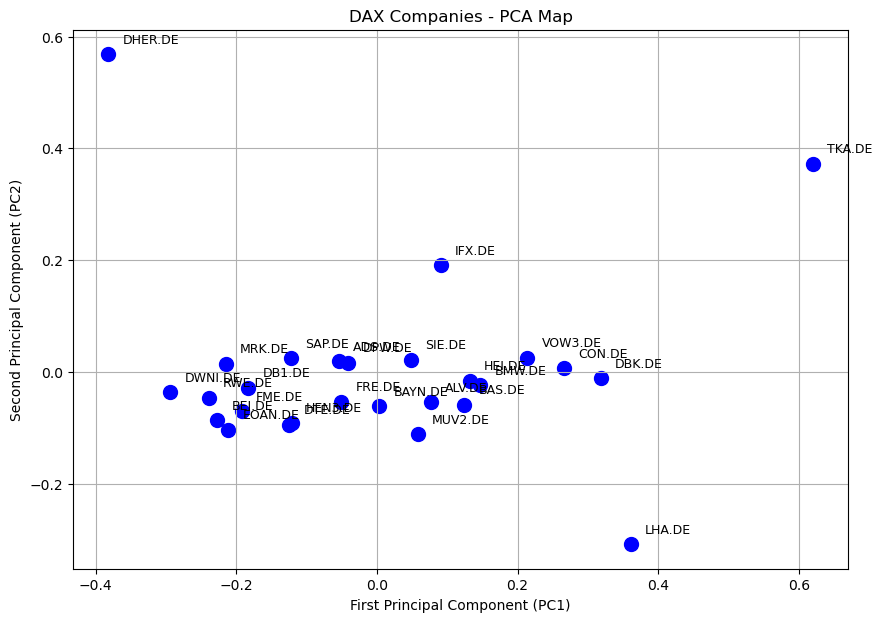

In [64]:
# Get the coordinates
x = pca_result[:, 0]  # PC1 (left-right)
y = pca_result[:, 1]  # PC2 (up-down)

# Make a bigger picture because we have more dots!
plt.figure(figsize=(10, 7))

# Draw blue dots for each company
plt.scatter(x, y, s=100, color="blue")

# Write company names next to each dot
company_names = list(portfolio.keys())

for i in range(len(company_names)):
    # Move text a little so it doesn't sit on the dot
    plt.text(x[i] + 0.02, y[i] + 0.02, company_names[i], fontsize=9)

# Add labels and grid
plt.xlabel("First Principal Component (PC1)")
plt.ylabel("Second Principal Component (PC2)")
plt.title("DAX Companies - PCA Map")
plt.grid(True)

# Show the map
plt.show()

### Exercise II.5

Let us make a simplifying assumption and consider 
that the DAX consist of the following seven industry sectors:

* commerce
* aviation and automotive
* bank and insurance
* chemicals and pharmaceuticals
* software and communication
* energy and construction
* technology and medicine
 
Perform k-means clustering on your PCA result. Under this assumption, use

In [65]:
k = 7
random_state = 123
n_init = 100

in your k-means clustering function.

In [66]:
# Create the robot
robot = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)

# Train the robot on our 2D DAX map
robot.fit(pca_result)

# Ask: "Which industry is each company in?"
cluster_labels = robot.predict(pca_result)

# Show the results!
company_names = list(portfolio.keys())

print("Industry assignments:")
for i in range(len(company_names)):
    print(f"  {company_names[i]} is in Industry {cluster_labels[i]}")

Industry assignments:
  ADS.DE is in Industry 4
  ALV.DE is in Industry 4
  BAS.DE is in Industry 6
  BAYN.DE is in Industry 4
  BEI.DE is in Industry 0
  BMW.DE is in Industry 6
  CON.DE is in Industry 6
  DB1.DE is in Industry 0
  DBK.DE is in Industry 6
  DHER.DE is in Industry 3
  DPW.DE is in Industry 4
  DTE.DE is in Industry 0
  DWNI.DE is in Industry 0
  EOAN.DE is in Industry 0
  FME.DE is in Industry 0
  FRE.DE is in Industry 4
  HEI.DE is in Industry 6
  HEN3.DE is in Industry 0
  IFX.DE is in Industry 5
  LHA.DE is in Industry 2
  MRK.DE is in Industry 0
  MUV2.DE is in Industry 4
  RWE.DE is in Industry 0
  SAP.DE is in Industry 0
  SIE.DE is in Industry 4
  TKA.DE is in Industry 1
  VOW3.DE is in Industry 6


### Exercise II.6

Visualise your result by plotting a similar figure as in Exercise I.6. 
Colour the data points by their cluster.

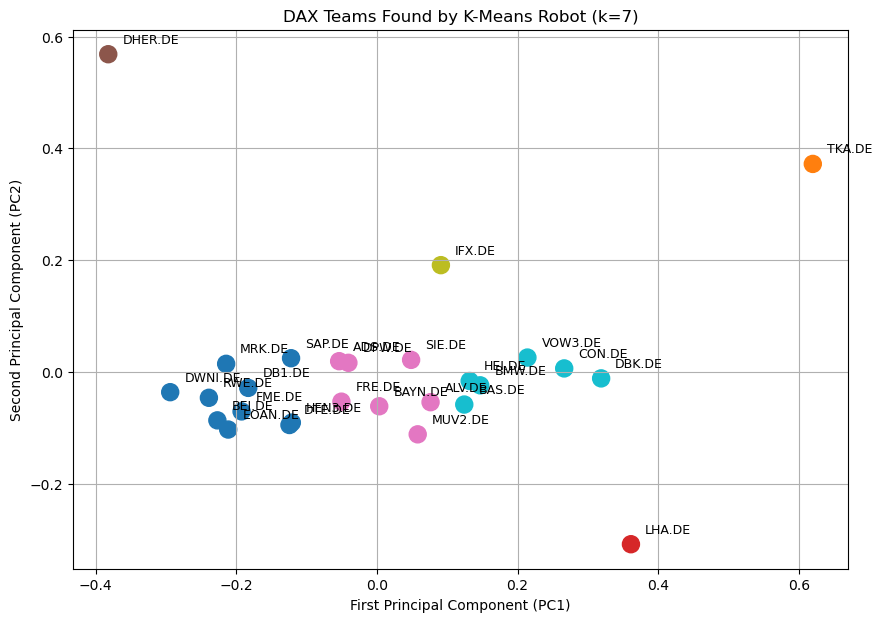

In [67]:
# Get coordinates
x = pca_result[:, 0]
y = pca_result[:, 1]

# Make the picture
plt.figure(figsize=(10, 7))

# Color the dots by team number!
plt.scatter(x, y, c=cluster_labels, cmap="tab10", s=150)

# Add company names
company_names = list(portfolio.keys())
for i in range(len(company_names)):
    plt.text(x[i] + 0.02, y[i] + 0.02, company_names[i], fontsize=9)

# Labels
plt.xlabel("First Principal Component (PC1)")
plt.ylabel("Second Principal Component (PC2)")
plt.title("DAX Teams Found by K-Means Robot (k=7)")
plt.grid(True)

plt.show()

As before, print the cluster number (0 to 6) and the stocks which belong to each cluster number.

Fill in the cell below:

In [ ]:
# Print all members of each team
company_names = list(portfolio.keys())

for industry_num in range(k):
    print(f"Industry {industry_num}:")

    members = []
    for i in range(len(company_names)):
        if cluster_labels[i] == team_num:
            members.append(company_names[i])

    print(" ", members)
    print()
# not so useful as we are using only 27% of the data, end up with clusters with single members. Perhaps bigger data sets need more components.

Industry 0:
  ['BEI.DE', 'DB1.DE', 'DTE.DE', 'DWNI.DE', 'EOAN.DE', 'FME.DE', 'HEN3.DE', 'MRK.DE', 'RWE.DE', 'SAP.DE']

Industry 1:
  ['TKA.DE']

Industry 2:
  ['LHA.DE']

Industry 3:
  ['DHER.DE']

Industry 4:
  ['ADS.DE', 'ALV.DE', 'BAYN.DE', 'DPW.DE', 'FRE.DE', 'MUV2.DE', 'SIE.DE']

Industry 5:
  ['IFX.DE']

Industry 6:
  ['BAS.DE', 'BMW.DE', 'CON.DE', 'DBK.DE', 'HEI.DE', 'VOW3.DE']



### Exercise II.7

**You do not need to write or execute anything in this exercise.**

As before, reflect on the following questions:

* Were you able to identify useful clusters?
* If you were or were not, why is that the case? Take your result on the expressivity (Exercise II.3) into consideration.
* Do you consider the simplification to two principal components useful for this second dataset, too?